# Single Source Dithered Mosaic

This notebook demonstrates the full Roman WFI simulation-to-mosaic pipeline for a single strong lensing system:

1. **Load** a `SyntheticImage` from the mejiro ray-tracing pipeline
2. **Simulate** 4 dithered L2 exposures with romanisim (using the `extra_counts` method from `romanisim_pipeline.py`)
3. **Combine** the L2 exposures into an L3 mosaic with the romancal `MosaicPipeline`

The BOXGAP4 gap-filling dither pattern is used, and the source is tracked at its true sky position across all 4 dithers so the mosaic correctly co-adds all observations.

**Environment:** `mejiro-v3` (romanisim 0.13.0, romancal 0.22.0)

In [15]:
import logging
logging.basicConfig(level=logging.WARNING, format='%(asctime)s %(levelname)s %(name)s: %(message)s')

import os
import copy
import json
import yaml

import asdf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy import table
from astropy.time import Time
from astropy.visualization import simple_norm

import galsim
import pysiaf
from romanisim import image, parameters, wcs as romanisim_wcs
import romanisim.bandpass
import roman_datamodels as rdm
from romancal.pipeline import MosaicPipeline
from romancal.associations import asn_from_list

import mejiro
from mejiro.utils import util as mejiro_util
from mejiro.point_wfi import PointWFI, find_source_position, compute_pixel_positions, plot_source_placement

# load config
config_file = os.path.join(os.path.dirname(os.path.dirname(mejiro.__file__)), 'projects', 'roman_data_challenge', 'roman_data_challenge_rung_1.yaml')
with open(config_file, 'r') as f:
    config = yaml.load(f, Loader=yaml.SafeLoader)

# parameters
SCA = 1
BAND = 'F158'
TILE_SIZE = 73

ma_table_number = config['exposure']['ma_table_number']
date = config['exposure']['date']
if not isinstance(date, str):
    date = date.isoformat()
coord = SkyCoord(
    ra=config['exposure']['coordinates']['ra'] * u.deg,
    dec=config['exposure']['coordinates']['dec'] * u.deg,
)
seed = config['seed']

read_pattern = parameters.read_pattern[ma_table_number]
exptime = parameters.read_time * read_pattern[-1][-1]
abflux = romanisim.bandpass.get_abflux(BAND, SCA)

# output directory
output_dir = os.path.join(config['data_dir'], config['pipeline_label'], 'notebook_mosaic')
os.makedirs(output_dir, exist_ok=True)

print(f'SCA:          {SCA:02d}')
print(f'Band:         {BAND}')
print(f'MA table:     {ma_table_number}  ->  {exptime:.1f} s exposure')
print(f'AB flux:      {abflux:.4e} e/s per maggy')
print(f'Observation:  {date}  |  RA={coord.ra.deg:.1f} deg, Dec={coord.dec.deg:.1f} deg')
print(f'Output dir:   {output_dir}')


SCA:          01
Band:         F158
MA table:     17  ->  610.4 s exposure
AB flux:      3.3809e+10 e/s per maggy
Observation:  2027-01-01T00:00:00  |  RA=270.0 deg, Dec=66.0 deg
Output dir:   /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic


## Dither Pattern

The `PointWFI` class (from `mejiro.point_wfi`) represents a Roman WFI pointing and can load dither patterns from the STScI-provided text files. Use `PointWFI.available_patterns()` to see all available patterns and `PointWFI.get_pattern(name)` to retrieve offset tuples.


In [16]:
# show all available dither patterns
print('Available dither patterns:')
for name in PointWFI.available_patterns():
    offsets = PointWFI.get_pattern(name)
    print(f'  {name:<15s}  ({len(offsets)} steps)')


Available dither patterns:
  BOXGAP4_1        (4 steps)
  BOXGAP4_2        (4 steps)
  BOXGAP5_1        (5 steps)
  BOXGAP5_2        (5 steps)
  BOXGAP6_1        (6 steps)
  BOXGAP6_2        (6 steps)
  BOXGAP7_1        (7 steps)
  BOXGAP7_2        (7 steps)
  BOXGAP8_1        (8 steps)
  BOXGAP8_2        (8 steps)
  BOXGAP9_1        (9 steps)
  BOXGAP9_2        (9 steps)
  LINEGAP2_1       (2 steps)
  LINEGAP2_2       (2 steps)
  LINEGAP2_3       (2 steps)
  LINEGAP2_4       (2 steps)
  LINEGAP3_1       (3 steps)
  LINEGAP3_2       (3 steps)
  LINEGAP3_3       (3 steps)
  LINEGAP3_4       (3 steps)
  LINEGAP4_1       (4 steps)
  LINEGAP4_2       (4 steps)
  LINEGAP4_3       (4 steps)
  LINEGAP4_4       (4 steps)
  LINEGAP5_1       (5 steps)
  LINEGAP5_2       (5 steps)
  LINEGAP5_3       (5 steps)
  LINEGAP5_4       (5 steps)
  SUB2             (2 steps)
  SUB3             (3 steps)
  SUB4             (4 steps)
  SUB5             (5 steps)
  SUB6             (6 steps)
  SUB7          

## BOXGAP4 Dither Pattern

The BOXGAP4 pattern provides four pointings optimized for filling the gaps between WFI detectors. Offsets are in arcseconds in the WFI ideal coordinate frame.

| Dither Step | Offset X (arcsec) | Offset Y (arcsec) |
| --- | --- | --- |
| 0 | 0.00 | 0.00 |
| 1 | -205.20 | 0.88 |
| 2 | -204.32 | 206.08 |
| 3 | 0.88 | 205.20 |

In [17]:
PA_APER = 0  # deg, aligns SCA01 detector rows with north

PATTERN_NAME = 'BOXGAP4_1'
DITHER_OFFSETS = PointWFI.get_pattern(PATTERN_NAME)

# compute the dithered boresight RA/Dec for each step
pointings = []
for x_off, y_off in DITHER_OFFSETS:
    p = PointWFI(ra=coord.ra.deg, dec=coord.dec.deg, position_angle=0.0)
    p.dither(x_off, y_off)
    pointings.append(SkyCoord(ra=p.ra * u.deg, dec=p.dec * u.deg))

print(f'Pattern: {PATTERN_NAME} ({len(DITHER_OFFSETS)} dithers)')
print(f'{"Step":<6} {"Offset X":<12} {"Offset Y":<12} {"RA (deg)":<14} {"Dec (deg)":<14}')
print('-' * 58)
for i, (off, pt) in enumerate(zip(DITHER_OFFSETS, pointings)):
    print(f'{i:<6} {off[0]:<12.2f} {off[1]:<12.2f} {pt.ra.deg:<14.6f} {pt.dec.deg:<14.6f}')


Pattern: BOXGAP4_1 (4 dithers)
Step   Offset X     Offset Y     RA (deg)       Dec (deg)     
----------------------------------------------------------
0      0.00         -0.00        270.000000     66.000000     
1      -205.20      0.88         270.069684     66.049470     
2      -204.32      206.08       269.947725     66.077765     
3      0.88         205.20       269.878201     66.028240     


## Load a Single SyntheticImage

Load one `SyntheticImage` from the stage-04 pipeline output. This is a 73x73 pixel ray-traced image of a strong gravitational lens system in surface-brightness units (counts/sec).

In [18]:
data_dir = os.path.join(config['data_dir'], config['pipeline_label'], '04')
pickle_path = os.path.join(data_dir, f'sca{SCA:02d}',
                           f'SyntheticImage_{config["pipeline_label"]}_00000001_{BAND}.pkl')
synth = mejiro_util.unpickle(pickle_path)

print(f'Pickle:       {pickle_path}')
print(f'Image shape:  {synth.data.shape}')
print(f'Band:         {synth.band}')
print(f'Maggies:      {synth.get_maggies():.6e}')
print(f'Total flux:   {synth.data.sum():.6e} counts/sec')

Pickle:       /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/04/sca01/SyntheticImage_roman_data_challenge_rung_1_00000001_F158.pkl
Image shape:  (73, 73)
Band:         F158
Maggies:      3.341056e-09
Total flux:   1.129505e+02 counts/sec


### Figure 1: Input SyntheticImage

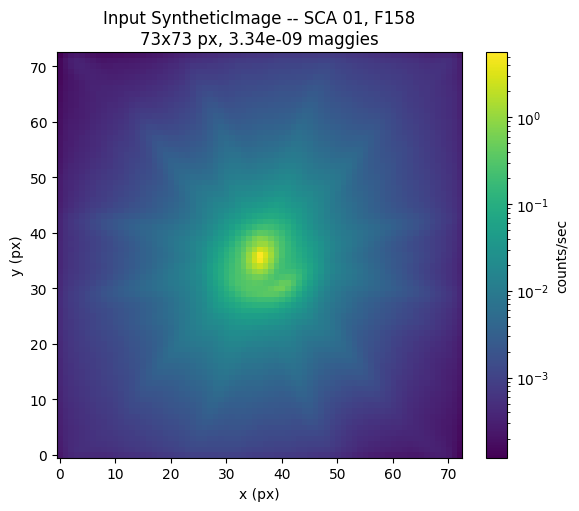

In [19]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
im = ax.imshow(synth.data, origin='lower', cmap='viridis',
               norm=LogNorm())
plt.colorbar(im, ax=ax, label='counts/sec')
ax.set_title(f'Input SyntheticImage -- SCA {SCA:02d}, {BAND}\n'
             f'{synth.data.shape[0]}x{synth.data.shape[1]} px, '
             f'{synth.get_maggies():.2e} maggies')
ax.set_xlabel('x (px)')
ax.set_ylabel('y (px)')
plt.savefig('figures/single_source_mosaic/input_synthetic_image.png', dpi=300)
plt.show()

## Convert to Electrons and Define Source Sky Position

Convert the surface-brightness image to electron counts using the AB flux zeropoint:

    electrons = (pixel / sum_pixels) * maggies * abflux * exptime

The source's "true" sky position is defined as the boresight of the undithered pointing (dither step 0). For each subsequent dither, the WCS will project this sky position to a different pixel location on the detector.

In [20]:
# smooth negative/NaN pixels
smooth_data = np.asarray(mejiro_util.smooth_pixels(synth.data), dtype=np.float64)

# convert surface brightness -> electrons
synth_sum = np.sum(smooth_data, dtype=np.float64)
maggies = synth.get_maggies()
total_electrons = maggies * abflux * exptime
lens_electrons = (smooth_data / synth_sum) * total_electrons

print(f'Total electrons: {total_electrons:.2f}')
print(f'Tile min/max:    {lens_electrons.min():.3e} / {lens_electrons.max():.3e} e-')

# Find the source sky position that lands on the detector for all dithers
result = find_source_position(
    pointings=pointings,
    sca=SCA,
    band=BAND,
    tile_size=TILE_SIZE,
    ma_table_number=ma_table_number,
    date=date,
    pa_aper=PA_APER,
)
source_sky_galsim = result.sky_coord
source_sky_coord = SkyCoord(
    ra=source_sky_galsim.ra.deg * u.deg,
    dec=source_sky_galsim.dec.deg * u.deg,
)


Total electrons: 68944.27
Tile min/max:    7.354e-02 / 3.400e+03 e-


## Compute Pixel Positions for Each Dither

For each dithered pointing, build the romanisim WCS and project the source's sky position onto the detector. The ~200 arcsec BOXGAP4 dithers shift the source by ~1800 pixels between exposures.

In [21]:
half_tile = TILE_SIZE // 2

pixel_positions = compute_pixel_positions(
    source_sky=source_sky_galsim,
    pointings=pointings,
    sca=SCA,
    band=BAND,
    tile_size=TILE_SIZE,
    ma_table_number=ma_table_number,
    date=date,
    pa_aper=PA_APER,
)


Step   Pixel X    Pixel Y    On detector?  
----------------------------------------
0      1113       1084       YES           
1      2977       1094       YES           
2      2978       3002       YES           
3      1112       2989       YES           


### Figure 2: Source Placement on Detector for Each Dither

Each panel shows the 4088x4088 detector footprint with the 73x73 source tile marked at its projected pixel position.

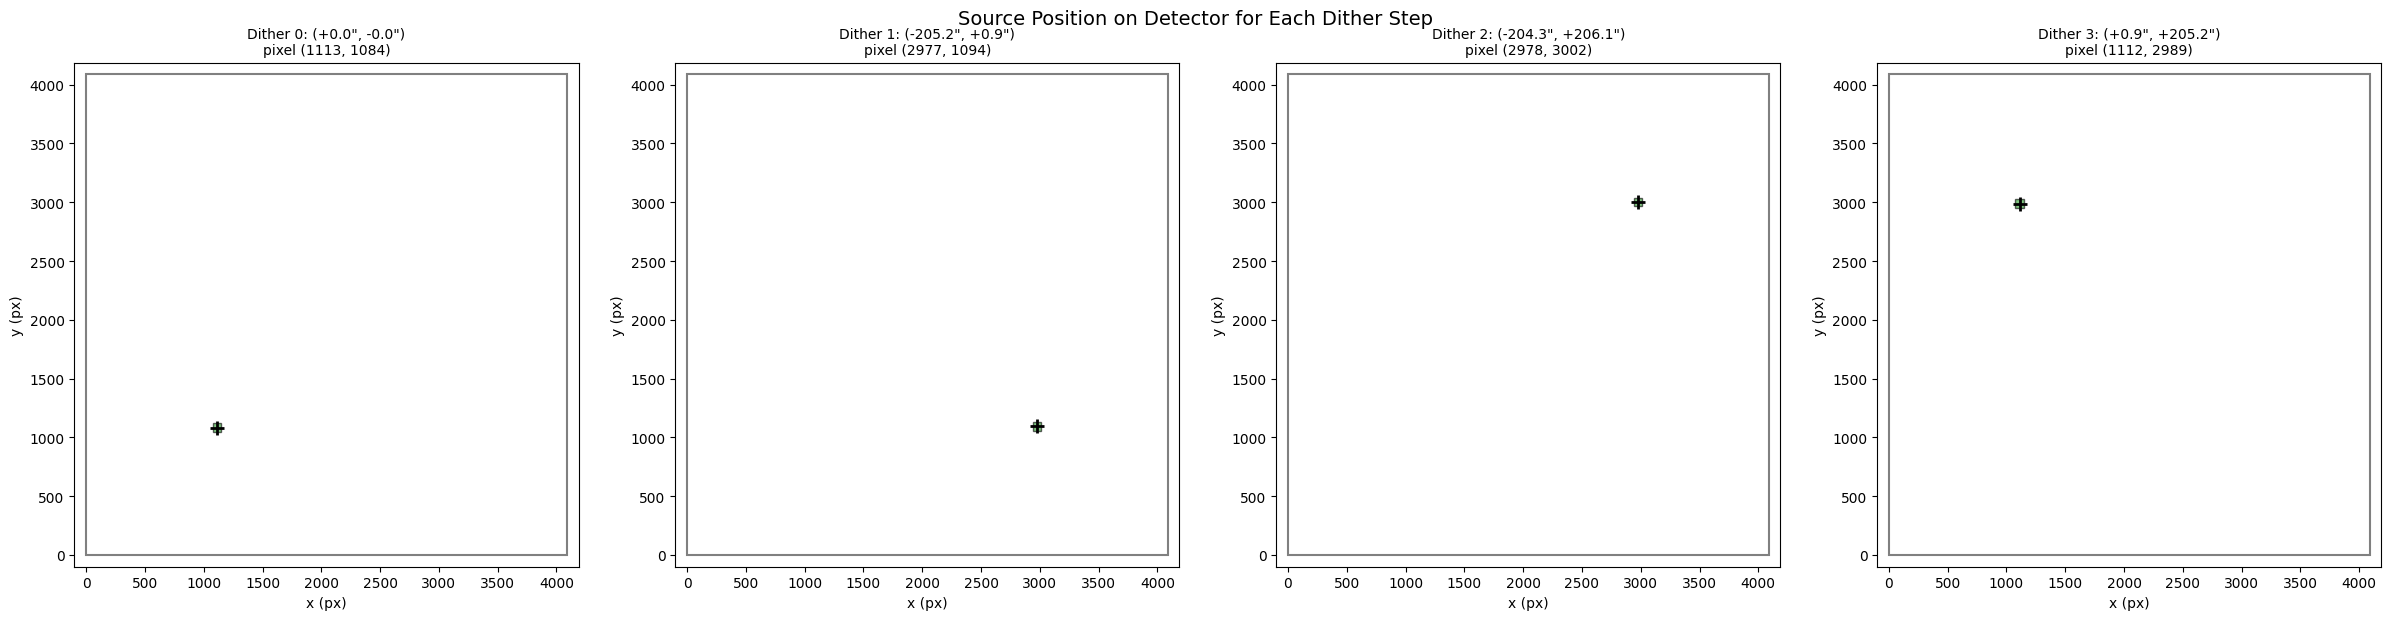

In [22]:
fig, axes = plot_source_placement(pixel_positions, DITHER_OFFSETS, TILE_SIZE)
plt.savefig('figures/single_source_mosaic/source_placement.png', dpi=300)
plt.show()


## Simulate 4 Dithered L2 Exposures

For each dither position, we:
1. Place the source electrons at the computed pixel position in a 4088x4088 array
2. Apply Poisson noise to create integer counts
3. Run `romanisim.image.simulate()` with `extra_counts` to apply the full detector-effects chain (ramp sampling, IPC, read noise, dark current, ramp fitting)
4. Save the resulting L2 image as an ASDF file

Each exposure uses an independent RNG seed so noise realizations differ.

**Note:** Each simulation takes several minutes. Total runtime for 4 exposures: ~15-30 minutes.

In [23]:
FORCE_SIMULATE = True  # set True to re-run romanisim even if files exist

l2_files = [
    os.path.join(output_dir, f'mejiro_dither{i + 1:04d}_wfi{SCA:02d}_{BAND.lower()}_cal.asdf')
    for i in range(len(pointings))
]

if not FORCE_SIMULATE and all(os.path.exists(p) for p in l2_files):
    print('L2 files already exist — skipping simulation. Loading data arrays...')
    l2_data = []
    for path in l2_files:
        with asdf.open(path) as af:
            l2_data.append(np.array(af['roman']['data']))
        print(f'  Loaded: {path}')
    print(f'\nLoaded {len(l2_files)} existing L2 exposures from {output_dir}')

else:
    l2_data = []

    for i, dithered_coord in enumerate(pointings):
        cx, cy, on_det = pixel_positions[i]
        print(f'\n=== Dither {i}: offset ({DITHER_OFFSETS[i][0]:+.1f}\", {DITHER_OFFSETS[i][1]:+.1f}\"), '
              f'pixel ({cx}, {cy}) ===')

        # 1. build extra_counts array with source at computed position
        counts = np.zeros((4088, 4088), dtype=np.float64)
        # clip placement to detector bounds
        src_y0 = max(cy - half_tile, 0)
        src_y1 = min(cy + half_tile + 1, 4088)
        src_x0 = max(cx - half_tile, 0)
        src_x1 = min(cx + half_tile + 1, 4088)
        # src_x1/src_y1 can be negative when the source center is far off the
        # left/bottom edge (numpy would misinterpret as relative-from-end indices),
        # so only place the tile when it genuinely overlaps the detector.
        if src_y1 > src_y0 and src_x1 > src_x0:
            tile_y0 = src_y0 - (cy - half_tile)
            tile_y1 = TILE_SIZE - ((cy + half_tile + 1) - src_y1)
            tile_x0 = src_x0 - (cx - half_tile)
            tile_x1 = TILE_SIZE - ((cx + half_tile + 1) - src_x1)
            counts[src_y0:src_y1, src_x0:src_x1] = lens_electrons[tile_y0:tile_y1, tile_x0:tile_x1]

        # 2. Poisson noise
        rng_np = np.random.default_rng(seed + i)
        realized = rng_np.poisson(np.clip(counts, 0, None)).astype(np.int32)
        extra_counts = galsim.ImageI(realized)
        print(f'  extra_counts: {realized.sum():.0f} total e-')

        # 3. set up romanisim metadata
        meta = copy.deepcopy(parameters.default_parameters_dictionary)
        meta['instrument']['detector'] = f'WFI{SCA:02d}'
        meta['instrument']['optical_element'] = BAND
        meta['exposure']['ma_table_number'] = ma_table_number
        meta['exposure']['read_pattern'] = read_pattern
        meta['exposure']['start_time'] = Time(date)
        romanisim_wcs.fill_in_parameters(meta, dithered_coord, boresight=True, pa_aper=PA_APER)

        # empty source catalog
        source_catalog = table.Table({
            'ra':                np.array([], dtype='f8'),
            'dec':               np.array([], dtype='f8'),
            'type':              np.array([], dtype='U3'),
            'n':                 np.array([], dtype='f4'),
            'half_light_radius': np.array([], dtype='f4'),
            'pa':                np.array([], dtype='f4'),
            'ba':                np.array([], dtype='f4'),
            BAND:                np.array([], dtype='f4'),
        })

        # 4. run romanisim simulation
        rng_galsim = galsim.UniformDeviate(seed + i)
        print(f'  Running romanisim (level=2)...')
        im, extras = image.simulate(
            meta, source_catalog,
            usecrds=False,
            psftype='galsim',
            level=2,
            rng=rng_galsim,
            crparam=dict(),
            extra_counts=extra_counts,
        )
        print(f'  Done. Output shape: {im["data"].shape}')

        # 5. save as ASDF
        # MosaicPipeline's FluxStep requires meta.cal_step to exist; romanisim does
        # not populate it, so inject the node manually before saving.
        im['meta']['cal_step'] = {
            'assign_wcs':        'COMPLETE',
            'dark':              'COMPLETE',
            'dark_decay':        'COMPLETE',
            'dq_init':           'COMPLETE',
            'flat_field':        'COMPLETE',
            'flux':              'N/A',
            'linearity':         'COMPLETE',
            'outlier_detection': 'N/A',
            'photom':            'COMPLETE',
            'source_catalog':    'N/A',
            'ramp_fit':          'COMPLETE',
            'refpix':            'COMPLETE',
            'saturation':        'COMPLETE',
            'skymatch':          'N/A',
            'tweakreg':          'N/A',
            'wfi18_transient':   'N/A',
        }
        filepath = l2_files[i]
        af = asdf.AsdfFile()
        af.tree = {'roman': im}
        af.write_to(filepath)
        print(f'  Saved: {filepath}')

        l2_data.append(np.array(im['data']))

    print(f'\nAll {len(pointings)} L2 exposures saved to {output_dir}')


=== Dither 0: offset (+0.0", -0.0"), pixel (1113, 1084) ===


2026-04-17 13:58:19,320 WARNING romanisim: --usecrds is not set.  romanisim will not use reference files from CRDS.  The WCS may be incorrect and up-to-date calibration information will not be used.
2026-04-17 13:58:19,339 INFO romanisim: Simulating filter F158...


  extra_counts: 68613 total e-
  Running romanisim (level=2)...


2026-04-17 13:58:19,795 INFO romanisim: Creating PSF using galsim
2026-04-17 13:58:20,341 INFO romanisim: Creating PSF using galsim
2026-04-17 13:58:20,783 INFO romanisim: Creating PSF using galsim
2026-04-17 13:58:21,225 INFO romanisim: Creating PSF using galsim
2026-04-17 13:58:24,714 INFO romanisim: Adding 0 sources to image...
2026-04-17 13:58:24,715 WARNING romanisim: You requested fastpointsources, but the PSF and/or chromaticity are incompatible with this setting.  Disabling fastpointsources.
2026-04-17 13:58:24,776 INFO romanisim: Rendered 0 point sources in 0.0417 seconds
2026-04-17 13:58:24,777 INFO romanisim: Rendered 0 total sources in 0.0613 seconds
2026-04-17 13:58:28,054 INFO romanisim: Apportioning electrons to resultants...
2026-04-17 14:03:14,469 INFO romanisim: Adding IPC...
2026-04-17 14:03:19,554 INFO romanisim: Adding read noise...
2026-04-17 14:03:26,383 INFO romanisim: Fitting ramps.
2026-04-17 14:03:56,077 INFO romanisim: Simulation complete.


  Done. Output shape: (4088, 4088)
  Saved: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic/mejiro_dither0001_wfi01_f158_cal.asdf

=== Dither 1: offset (-205.2", +0.9"), pixel (2977, 1094) ===


...

  Done. Output shape: (4088, 4088)
  Saved: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic/mejiro_dither0003_wfi01_f158_cal.asdf

=== Dither 3: offset (+0.9", +205.2"), pixel (1112, 2989) ===


2026-04-17 14:14:52,249 WARNING romanisim: --usecrds is not set.  romanisim will not use reference files from CRDS.  The WCS may be incorrect and up-to-date calibration information will not be used.
2026-04-17 14:14:52,256 INFO romanisim: Simulating filter F158...


  extra_counts: 69096 total e-
  Running romanisim (level=2)...


2026-04-17 14:14:52,631 INFO romanisim: Creating PSF using galsim
2026-04-17 14:14:52,993 INFO romanisim: Creating PSF using galsim
2026-04-17 14:14:53,355 INFO romanisim: Creating PSF using galsim
2026-04-17 14:14:53,720 INFO romanisim: Creating PSF using galsim
2026-04-17 14:14:57,219 INFO romanisim: Adding 0 sources to image...
2026-04-17 14:14:57,220 WARNING romanisim: You requested fastpointsources, but the PSF and/or chromaticity are incompatible with this setting.  Disabling fastpointsources.
2026-04-17 14:14:57,283 INFO romanisim: Rendered 0 point sources in 0.0438 seconds
2026-04-17 14:14:57,284 INFO romanisim: Rendered 0 total sources in 0.0634 seconds
2026-04-17 14:15:00,553 INFO romanisim: Apportioning electrons to resultants...
2026-04-17 14:19:36,597 INFO romanisim: Adding IPC...
2026-04-17 14:19:41,067 INFO romanisim: Adding read noise...
2026-04-17 14:19:47,741 INFO romanisim: Fitting ramps.
2026-04-17 14:20:16,496 INFO romanisim: Simulation complete.


  Done. Output shape: (4088, 4088)
  Saved: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic/mejiro_dither0004_wfi01_f158_cal.asdf

All 4 L2 exposures saved to /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic


In [24]:
import glob as glob_mod
import asdf

# Edit cal_step entries here, then run this cell to update all L2 files in output_dir.
cal_step_overrides = {
    'assign_wcs':        'COMPLETE',
    'dark':              'COMPLETE',
    'dark_decay':        'COMPLETE',
    'dq_init':           'COMPLETE',
    'flat_field':        'COMPLETE',
    'flux':              'N/A',
    'linearity':         'COMPLETE',
    'outlier_detection': 'N/A',
    'photom':            'COMPLETE',
    'source_catalog':    'N/A',
    'ramp_fit':          'COMPLETE',
    'refpix':            'COMPLETE',
    'saturation':        'COMPLETE',
    'skymatch':          'N/A',
    'tweakreg':          'N/A',
    'wfi18_transient':   'N/A',
}

l2_files = sorted(glob_mod.glob(os.path.join(output_dir, '*_cal.asdf')))
print(f'Found {len(l2_files)} L2 files')
for path in l2_files:
    with asdf.open(path, mode='rw') as af:
        af['roman']['meta']['cal_step'].update(cal_step_overrides)
        af.write_to(path)
    print(f'  Updated: {path}')

Found 4 L2 files
  Updated: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic/mejiro_dither0001_wfi01_f158_cal.asdf
  Updated: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic/mejiro_dither0002_wfi01_f158_cal.asdf
  Updated: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic/mejiro_dither0003_wfi01_f158_cal.asdf
  Updated: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic/mejiro_dither0004_wfi01_f158_cal.asdf


### Figure 3: Four L2 Exposures (Full Detector)

Each panel shows the full 4088x4088 L2 image. The source appears at a different pixel position in each dither step.

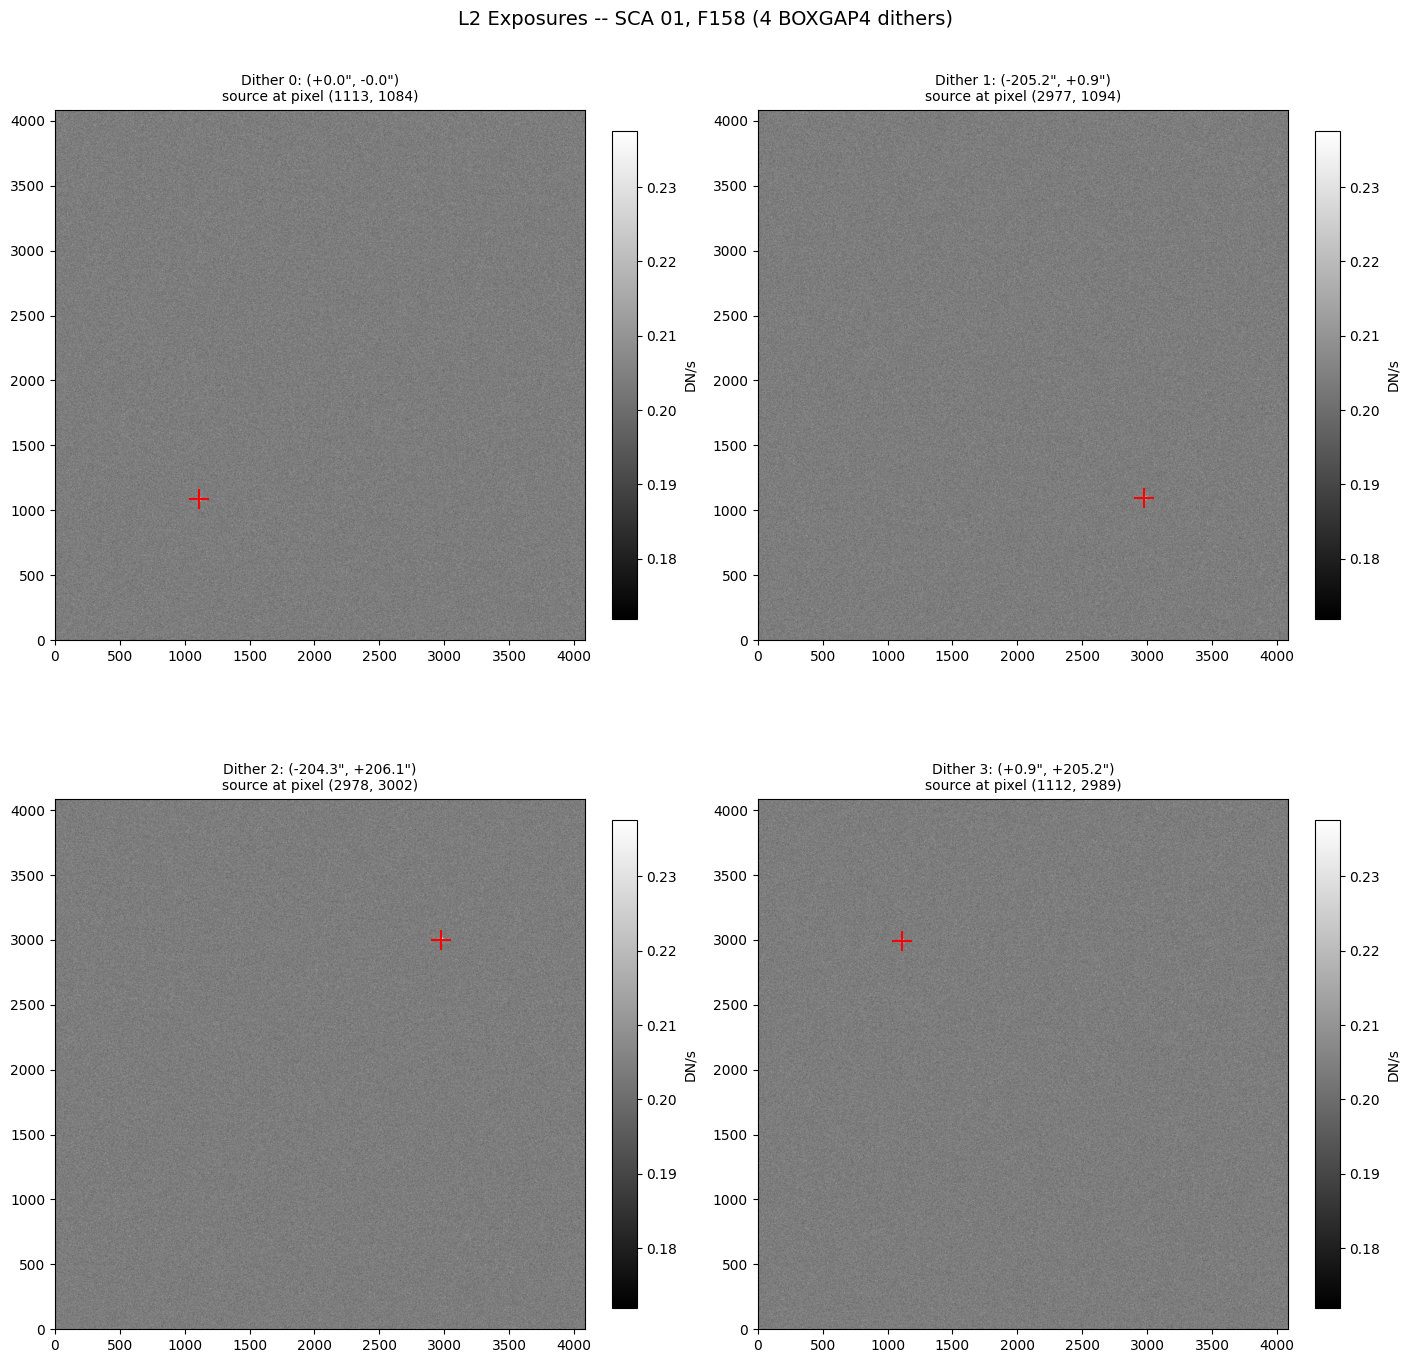

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14), constrained_layout=True)
fig.suptitle(f'L2 Exposures -- SCA {SCA:02d}, {BAND} (4 BOXGAP4 dithers)', fontsize=14)

# common scale across all panels
all_vals = np.concatenate([d[np.isfinite(d)].flatten() for d in l2_data])
vmin_full = np.percentile(all_vals, 1)
vmax_full = np.percentile(all_vals, 99)

for i, ax in enumerate(axes.flat):
    cx, cy, _ = pixel_positions[i]
    x_off, y_off = DITHER_OFFSETS[i]

    im = ax.imshow(l2_data[i], origin='lower', cmap='gray', vmin=vmin_full, vmax=vmax_full)
    plt.colorbar(im, ax=ax, label='DN/s', fraction=0.046, pad=0.04)

    # mark source position
    ax.plot(cx, cy, 'r+', ms=15, mew=1.5)
    ax.set_title(f'Dither {i}: ({x_off:+.1f}", {y_off:+.1f}")\nsource at pixel ({cx}, {cy})',
                 fontsize=10)

plt.savefig('figures/single_source_mosaic/l2_exposures.png', dpi=300)
plt.show()

### Figure 4: Zoomed Cutouts Around the Source

A 150x150 pixel cutout centered on the source in each dither. The source is the same object at the same sky position, but at different detector locations with independent noise realizations.

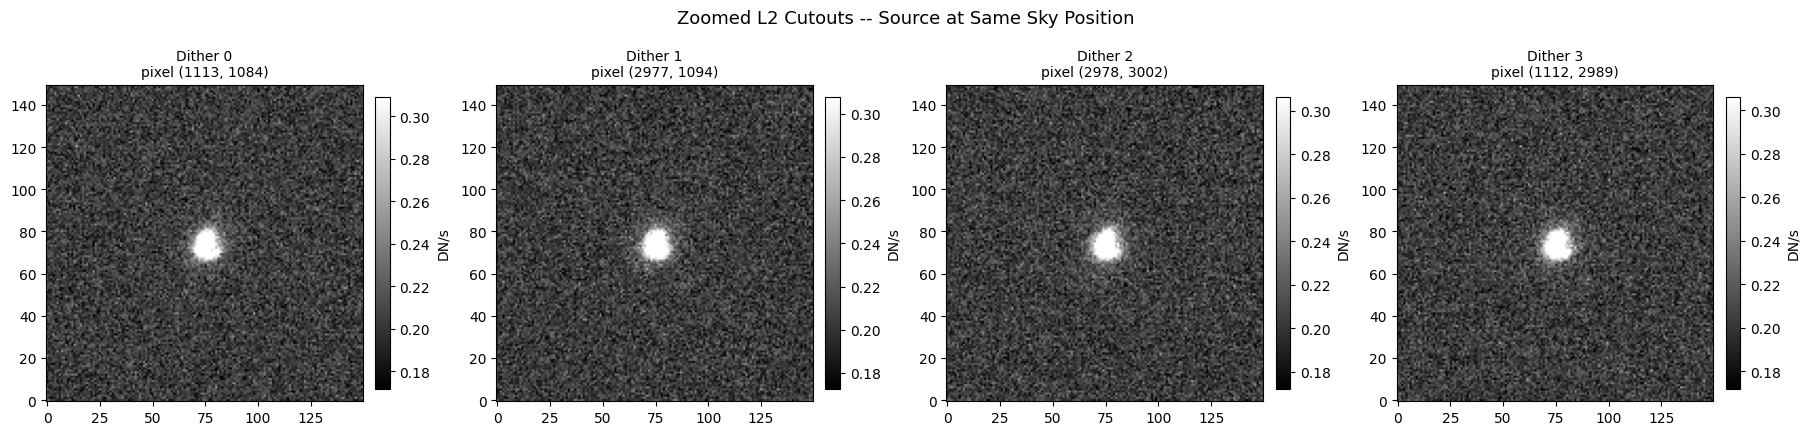

In [26]:
cutout_half = 75  # 150x150 pixel cutouts

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), constrained_layout=True)
fig.suptitle(f'Zoomed L2 Cutouts -- Source at Same Sky Position', fontsize=13)

for i, ax in enumerate(axes.flat):
    cx, cy, _ = pixel_positions[i]
    y0 = max(cy - cutout_half, 0)
    y1 = min(cy + cutout_half, 4088)
    x0 = max(cx - cutout_half, 0)
    x1 = min(cx + cutout_half, 4088)
    cutout = l2_data[i][y0:y1, x0:x1]

    vmin_c = np.nanpercentile(cutout, 1)
    vmax_c = np.nanpercentile(cutout, 99.5)
    im = ax.imshow(cutout, origin='lower', cmap='gray', vmin=vmin_c, vmax=vmax_c)
    plt.colorbar(im, ax=ax, label='DN/s', fraction=0.046, pad=0.04)
    ax.set_title(f'Dither {i}\npixel ({cx}, {cy})', fontsize=10)

plt.savefig('figures/single_source_mosaic/l2_cutouts_zoomed.png', dpi=300)
plt.show()

## Create Association File and Run MosaicPipeline

The romancal `MosaicPipeline` combines multiple L2 exposures into an L3 mosaic. It requires a JSON association file listing the input L2 products. The pipeline applies:

1. **Flux step**: DN/s -> MJy/sr
2. **Skymatch**: match flux levels in overlapping regions
3. **Outlier detection**: flag outlier pixels
4. **Resample**: drizzle-combine onto a common sky grid

In [27]:
product_name = 'mejiro_mosaic'
asn_path = os.path.join(output_dir, f'{product_name}_asn.json')

if not FORCE_SIMULATE and os.path.exists(asn_path):
    print(f'Association file already exists — skipping rebuild.')
    print(f'Association file: {asn_path}')
else:
    asn = asn_from_list.asn_from_list(
        [(f, 'science') for f in l2_files],
        product_name=product_name,
        with_exptype=True,
        target='',
    )
    _, serialized = asn.dump(format='json')
    with open(asn_path, 'w') as f:
        f.write(serialized)
    print(f'Association file: {asn_path}')
    print(f'Input files:      {len(l2_files)}')
    print(json.dumps(json.loads(serialized), indent=2))

Association file: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic/mejiro_mosaic_asn.json
Input files:      4
{
  "asn_type": "None",
  "asn_rule": "DMS_ELPP_Base",
  "version_id": null,
  "code_version": "0.22.0",
  "target": "",
  "degraded_status": "No known degraded exposures in association.",
  "program": "noprogram",
  "data_release_id": "p",
  "constraints": "No constraints",
  "asn_id": "a3001",
  "asn_pool": "none",
  "skycell_wcs_info": "none",
  "products": [
    {
      "name": "mejiro_mosaic",
      "members": [
        {
          "expname": "/nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic/mejiro_dither0001_wfi01_f158_cal.asdf",
          "exptype": "science"
        },
        {
          "expname": "/nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic/mejiro_dither0002_wfi01_f158_cal.asdf",
          "exptype": "science"
        },
        {
          "expname": "/nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/no

In [28]:
# romanisim (usecrds=False) stores negative placeholder values for photometric conversion.
# The FluxStep multiplies data by conversion_megajanskys, so negative values produce an
# all-negative mosaic. Fix by taking the absolute value before running MosaicPipeline.
for path in l2_files:
    with asdf.open(path, mode='rw') as af:
        phot = af['roman']['meta']['photometry']
        phot['conversion_megajanskys'] = abs(float(phot['conversion_megajanskys']))
        phot['pixel_area']             = abs(float(phot['pixel_area']))
        af.write_to(path)
    print(f'  Patched photometry: {os.path.basename(path)}')

  Patched photometry: mejiro_dither0001_wfi01_f158_cal.asdf
  Patched photometry: mejiro_dither0002_wfi01_f158_cal.asdf
  Patched photometry: mejiro_dither0003_wfi01_f158_cal.asdf
  Patched photometry: mejiro_dither0004_wfi01_f158_cal.asdf


In [29]:
print('Running MosaicPipeline...')
result = MosaicPipeline.call(
    asn_path,
    save_results=True,
    output_dir=output_dir,
    resample_on_skycell=False,
    steps={
        'skymatch': {'skip': True},
        'outlier_detection': {'skip': True},
        'source_catalog': {'skip': True},
    },
)
print('MosaicPipeline complete.')

2026-04-17 14:20:53,532 - py.warnings - WARNING - /data/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/roman_datamodels/datamodels/_utils.py:291: FilenameMismatchWarning: meta.filename: ? does not match filename: mejiro_dither0001_wfi01_f158_cal.asdf, updating the filename in memory!
  asdf_file = init if isinstance(init, asdf.AsdfFile) else _open_asdf(init, memmap=memmap, **kwargs)

2026-04-17 14:20:53,532 WARNING py.warnings: /data/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/roman_datamodels/datamodels/_utils.py:291: FilenameMismatchWarning: meta.filename: ? does not match filename: mejiro_dither0001_wfi01_f158_cal.asdf, updating the filename in memory!
  asdf_file = init if isinstance(init, asdf.AsdfFile) else _open_asdf(init, memmap=memmap, **kwargs)



Running MosaicPipeline...


2026-04-17 14:20:54,041 - CRDS - ERROR -  Error determining best reference for 'pars-fluxstep'  =   No match found.
2026-04-17 14:20:54,043 - CRDS - ERROR -  Error determining best reference for 'pars-skymatchstep'  =   No match found.
2026-04-17 14:20:54,044 - CRDS - ERROR -  Error determining best reference for 'pars-outlierdetectionstep'  =   No match found.
2026-04-17 14:20:54,046 - CRDS - ERROR -  Error determining best reference for 'pars-resamplestep'  =   No match found.
2026-04-17 14:20:54,048 - CRDS - ERROR -  Error determining best reference for 'pars-sourcecatalogstep'  =   Unknown reference type 'pars-sourcecatalogstep'
2026-04-17 14:20:54,049 - CRDS - ERROR -  Error determining best reference for 'pars-mosaicpipeline'  =   Unknown reference type 'pars-mosaicpipeline'
2026-04-17 14:20:54,057 - stpipe.step - INFO - MosaicPipeline instance created.
2026-04-17 14:20:54,057 INFO stpipe.step: MosaicPipeline instance created.
2026-04-17 14:20:54,059 - stpipe.step - INFO - FluxSt

Maximum specified SIP approximation error: 5   - SIP degree: 1. Maximum residual: 0.0070717* Maximum residual, double sampled grid: 0.0070717* Final SIP degree: 1. Maximum residual: 0.0070717

2026-04-17 14:20:58,706 - stcal.resample.resample - INFO - Resampling science and variance data
2026-04-17 14:20:58,706 INFO stcal.resample.resample: Resampling science and variance data
2026-04-17 14:21:08,699 - stcal.resample.resample - INFO - Drizzling (4088, 4088) --> (8151, 8157)
2026-04-17 14:21:08,699 INFO stcal.resample.resample: Drizzling (4088, 4088) --> (8151, 8157)
2026-04-17 14:21:13,124 - stcal.resample.resample - INFO - Drizzling (4088, 4088) --> (8151, 8157)
2026-04-17 14:21:13,124 INFO stcal.resample.resample: Drizzling (4088, 4088) --> (8151, 8157)
2026-04-17 14:21:21,771 - stcal.resample.resample - INFO - Resampling science and variance data
2026-04-17 14:21:21,771 INFO stcal.resample.resample: Resampling science and variance data
2026-04-17 14:21:31,000 - stcal.resample.resample - INFO - Drizzling (4088, 4088) --> (8151, 8157)
2026-04-17 14:21:31,000 INFO stcal.resample.resample: Drizzling (4088, 4088) --> (8151, 8157)
2026-04-17 14:21:35,566 - stcal.resample.resamp

MosaicPipeline complete.


## Inspect the L3 Mosaic

In [30]:
import glob as glob_mod
mosaic_files = glob_mod.glob(os.path.join(output_dir, '*_coadd.asdf'))
print(f'Mosaic files found: {mosaic_files}')

mosaic_path = mosaic_files[0]
mos_file = rdm.open(mosaic_path)
mos_file.info()

print(f'\nMosaic data shape: {mos_file.data.shape}')
print(f'Mosaic data dtype: {mos_file.data.dtype}')
print(f'Data range: {np.nanmin(mos_file.data):.4e} to {np.nanmax(mos_file.data):.4e} MJy/sr')

Mosaic files found: ['/nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic/mejiro_mosaic_coadd.asdf']
root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 5.1.0
├─history (AsdfDictNode)
│ └─extensions (AsdfListNode)
│   ├─0 (ExtensionMetadata) ...
│   ├─1 (ExtensionMetadata) ...
│   ├─2 (ExtensionMetadata) ...
│   ├─3 (ExtensionMetadata) ...
│   ├─4 (ExtensionMetadata) ...
│   └─3 not shown
└─roman (WfiMosaic) # The schema for WFI Level 3 mosaics.
  ├─meta (AsdfDictNode) # Common Level 3 Metadata ...
  ├─data (NDArrayType) # Science Data (MJy / steradian) ...
  ├─context (NDArrayType) # Context Data ...
  ├─err (NDArrayType) # Error Data (MJy / steradian) ...
  ├─weight (NDArrayType) # Weight Data ...
  ├─var_poisson (NDArrayType) # Poisson Variability (MJy^2 / steradian^2) ...
  ├─var_rnoise (NDArrayType) # Read Noise Variance (MJy^2 / steradian^2 

### Figure 5: L3 Mosaic

The co-added mosaic in MJy/sr. Since all 4 dithered exposures observe the same source at the same sky position, the mosaic should show a single co-added source with improved signal-to-noise.

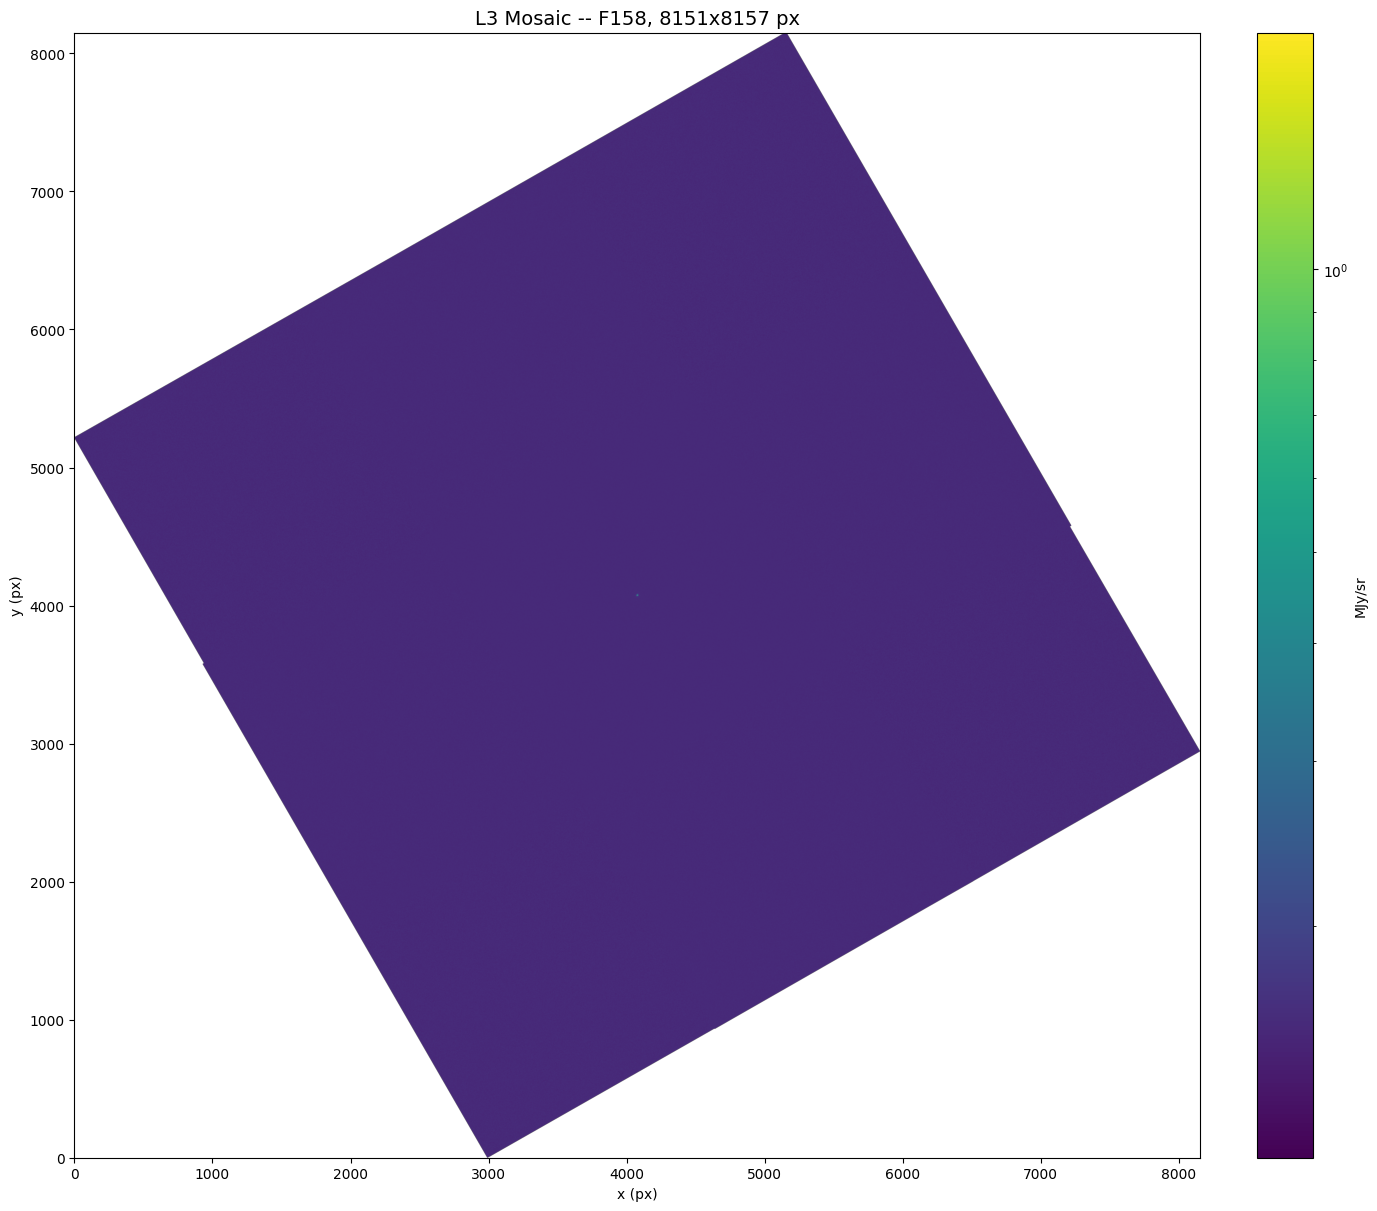

In [31]:
fig, ax = plt.subplots(figsize=(16, 12), constrained_layout=True)

mos_data = np.array(mos_file.data, dtype=float)
vmin_mos = np.nanpercentile(mos_data[np.isfinite(mos_data)], 1)
vmax_mos = np.nanpercentile(mos_data[np.isfinite(mos_data)], 99.5)
norm = simple_norm(mos_data[np.isfinite(mos_data)], 'asinh', vmin=vmin_mos, vmax=vmax_mos)

im = ax.imshow(mos_data, origin='lower', norm=LogNorm(), cmap='viridis')
plt.colorbar(im, ax=ax, label='MJy/sr', fraction=0.046, pad=0.04)
ax.set_title(f'L3 Mosaic -- {BAND}, {mos_data.shape[0]}x{mos_data.shape[1]} px', fontsize=14)
ax.set_xlabel('x (px)')
ax.set_ylabel('y (px)')
plt.savefig('figures/single_source_mosaic/l3_mosaic.png', dpi=300)
plt.show()

### Figure 6: Context and Weight Maps

- **Context**: which input images contributed to each output pixel
- **Weight**: relative coverage from the input images

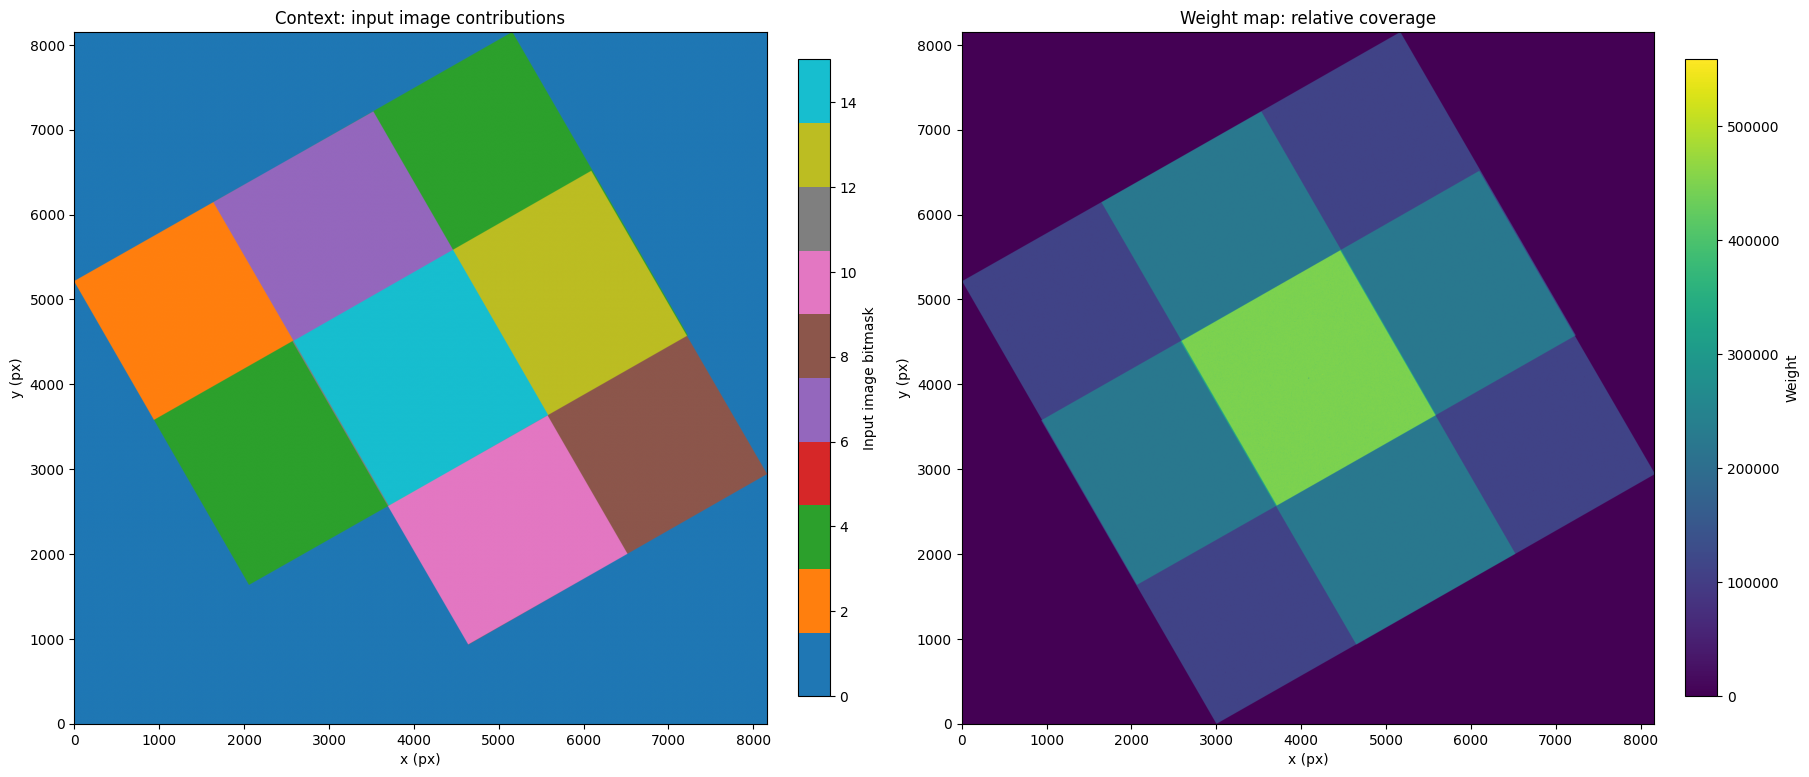

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

# context map
ctx = np.array(mos_file.context[0], dtype=float)
im0 = axes[0].imshow(ctx, origin='lower', cmap='tab10')
plt.colorbar(im0, ax=axes[0], label='Input image bitmask', fraction=0.046, pad=0.04)
axes[0].set_title('Context: input image contributions', fontsize=12)
axes[0].set_xlabel('x (px)')
axes[0].set_ylabel('y (px)')

# weight map
wt = np.array(mos_file.weight, dtype=float)
im1 = axes[1].imshow(wt, origin='lower', cmap='viridis')
plt.colorbar(im1, ax=axes[1], label='Weight', fraction=0.046, pad=0.04)
axes[1].set_title('Weight map: relative coverage', fontsize=12)
axes[1].set_xlabel('x (px)')
axes[1].set_ylabel('y (px)')

plt.savefig('figures/single_source_mosaic/context_and_weight.png', dpi=300)
plt.show()

### Figure 7: Pipeline Comparison -- Input vs L2 vs L3

Three-panel comparison showing the full journey of the source through the pipeline:

1. **Input**: Original ray-traced SyntheticImage (counts/sec)
2. **L2**: Single dither exposure after romanisim detector simulation (DN/s)
3. **L3**: Co-added mosaic from 4 dithered exposures (MJy/sr)

The L3 mosaic cutout is extracted using the WCS to locate the source's sky position on the mosaic grid.

Source in mosaic: pixel (4079, 4074)


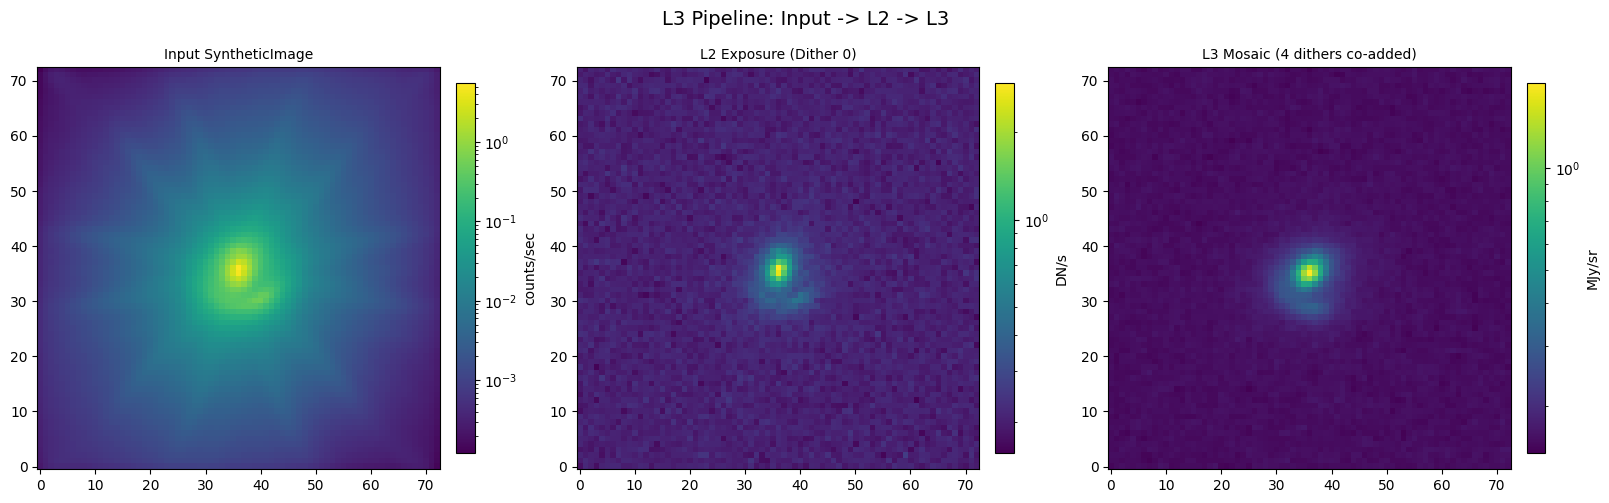

In [33]:
from matplotlib.colors import SymLogNorm

# find the source in the L3 mosaic using the mosaic WCS
mos_wcs = mos_file.meta.wcs
mos_x, mos_y = mos_wcs.world_to_pixel(source_sky_coord)
mos_cx, mos_cy = int(round(float(mos_x))), int(round(float(mos_y)))
print(f'Source in mosaic: pixel ({mos_cx}, {mos_cy})')

# extract cutouts
# L2 cutout (from dither 0)
cx0, cy0, _ = pixel_positions[0]
l2_cutout = l2_data[0][max(cy0-half_tile, 0):min(cy0+half_tile+1, 4088),
                       max(cx0-half_tile, 0):min(cx0+half_tile+1, 4088)]

# L3 cutout
mos_cutout = mos_data[max(mos_cy-half_tile, 0):min(mos_cy+half_tile+1, mos_data.shape[0]),
                      max(mos_cx-half_tile, 0):min(mos_cx+half_tile+1, mos_data.shape[1])]

# plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle('L3 Pipeline: Input -> L2 -> L3', fontsize=14)

# input
im0 = axes[0].imshow(synth.data, origin='lower', cmap='viridis', norm=LogNorm())
plt.colorbar(im0, ax=axes[0], label='counts/sec', fraction=0.046, pad=0.04)
axes[0].set_title(f'Input SyntheticImage', fontsize=10)

# L2
im1 = axes[1].imshow(l2_cutout, origin='lower', cmap='viridis', norm=LogNorm())
plt.colorbar(im1, ax=axes[1], label='DN/s', fraction=0.046, pad=0.04)
axes[1].set_title(f'L2 Exposure (Dither 0)', fontsize=10)

# L3 — use SymLogNorm so negatives/zeros are shown without clipping
pos_vals = mos_cutout[mos_cutout > 0]
# linthresh = float(np.percentile(pos_vals, 10)) if pos_vals.size else 1e-6
# mos_norm = SymLogNorm(linthresh=linthresh, vmin=mos_cutout.min(), vmax=mos_cutout.max())
im2 = axes[2].imshow(np.flip(mos_cutout.T, axis=(0,1)), origin='lower', cmap='viridis', norm=LogNorm())
plt.colorbar(im2, ax=axes[2], label='MJy/sr', fraction=0.046, pad=0.04)
axes[2].set_title(f'L3 Mosaic (4 dithers co-added)',
                  fontsize=10)

plt.savefig('figures/single_source_mosaic/l3_pipeline_summary.png', dpi=300)
plt.show()